In [1]:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import sys

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')
sys.path.insert(0, '../../../../..')

# Decoding
import suffix_pred.evalaution.decode_test_set_suffixes
importlib.reload(suffix_pred.evalaution.decode_test_set_suffixes)
from suffix_pred.evalaution.decode_test_set_suffixes import TestSetSuffixDecoder, DecodingConfig

# Evaluation metrics
import suffix_pred.evalaution.evalaution_metrics
importlib.reload(suffix_pred.evalaution.evalaution_metrics)
from suffix_pred.evalaution.evalaution_metrics import evaluate_dls, dls_per_prefix_length, average_dls

# Model
import suffix_pred.models.C_LSTM
importlib.reload(suffix_pred.models.C_LSTM)
from suffix_pred.models.C_LSTM import FullShared_Join_LSTM

In [2]:
# Model
file_path_model = '../../../../../../models/Procurement/clean/Procurement_C_LSTM_v1_clean.pkl'
model = FullShared_Join_LSTM.load(file_path_model)

# Load the data
# Path to your pickle file (saved with torch.save)
file_path_test = '../../../../../../data/Procurement/tensor_data/normal/procurement_all_5_test.pkl'
# Load the dataset using torch.load
test_dataset = torch.load(file_path_test, weights_only=False)

Data set categories:  ([('concept:name', 18, {'Approve Invoice': 1, 'Approve Requisition': 2, 'Close Case': 3, 'Collect Quotations': 4, 'Create Purchase Order': 5, 'Create Purchase Requisition': 6, 'EOS': 7, 'Evaluate Quotations': 8, 'Flag Invoice Mismatch': 9, 'Pay Invoice': 10, 'Receive Goods': 11, 'Reject Requisition': 12, 'Reorder Goods': 13, 'Request Credit Note': 14, 'Revise Requisition': 15, 'Select Supplier': 16, 'Send Purchase Order': 17}), ('org:resource', 22, {'Alice': 1, 'Bob': 2, 'Buyer_1': 3, 'Buyer_2': 4, 'Buyer_3': 5, 'Carol': 6, 'Clerk_1': 7, 'Clerk_2': 8, 'Clerk_3': 9, 'David': 10, 'EOS': 11, 'Eva': 12, 'Frank': 13, 'Manager_FIN_1': 14, 'Manager_FIN_2': 15, 'Manager_IT_1': 16, 'Manager_IT_2': 17, 'Manager_OPS_1': 18, 'Manager_OPS_2': 19, 'Receiver_A': 20, 'Receiver_B': 21}), ('budget_status', 4, {'EOS': 1, 'approved': 2, 'pending': 3}), ('supplier_type', 6, {'EOS': 1, 'preferred': 2, 'risky': 3, 'standard': 4, nan: 5}), ('goods_match', 5, {'EOS': 1, 'False': 2, 'True'

/home/PSPLab/.local/share/virtualenvs/decision_aware_augmentation_for_PPM-0DzgvVpC/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [3]:
# Step 1: Decode suffixes (mode / arg-max)
config = DecodingConfig(concept_name="concept:name",
                        eos_value="EOS")

decoder = TestSetSuffixDecoder(model=model, dataset=test_dataset, config=config)

mode = "mode"
outputs = decoder.decode(mode=mode,
                         random_order=False,
                         cache_path='../../../../../../eval_results/Procurement/clean/procurement_c_lstm_clean_outputs.pkl',
                         reuse_cache=False)

print(f"Decoded {len(outputs)} prefix rows in '{mode}' mode")

# Step 2: Evaluate DLS from decoded outputs
mode_df = evaluate_dls(outputs)
mode_per_prefix = dls_per_prefix_length(mode_df)
mode_avg = average_dls(mode_df)

print(f"Average DLS ({mode}) on full test set: {mode_avg:.4f}")

  0%|          | 0/2000 [00:00<?, ?it/s]

Decoded 23584 prefix rows in 'mode' mode
Average DLS (mode) on full test set: 0.7964


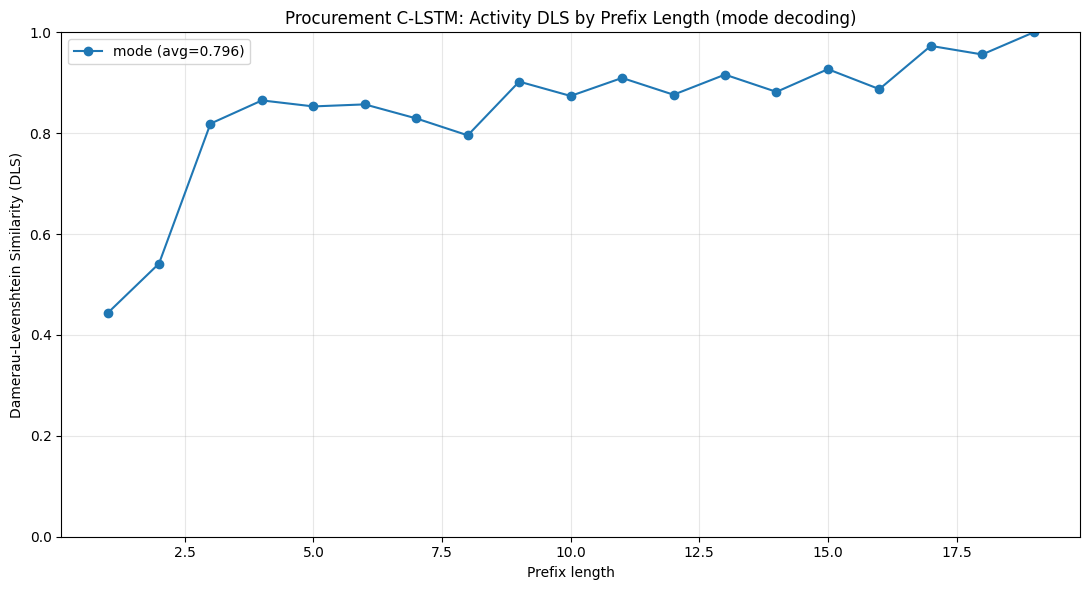

,mode,average_dls
0,mode,0.796439


In [4]:
# One combined plot (single method requested: mode decoding only)
plt.figure(figsize=(11, 6))

plt.plot(mode_per_prefix["prefix_len"],
         mode_per_prefix["dls"],
         marker="o",
         label=f"mode (avg={mode_avg:.3f})")

plt.title("Procurement C-LSTM: Activity DLS by Prefix Length (mode decoding)")
plt.xlabel("Prefix length")
plt.ylabel("Damerau-Levenshtein Similarity (DLS)")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional summary table
summary = pd.DataFrame({"mode": [mode], "average_dls": [mode_avg]}).sort_values("average_dls", ascending=False).reset_index(drop=True)
summary

In [5]:
# Load decoded outputs from pickle and inspect 5 example prefixes
from suffix_pred.evalaution.evalaution_metrics import load_decoded_suffixes

cached_outputs = load_decoded_suffixes('../../../../../../eval_results/Procurement/clean/procurement_c_lstm_clean_outputs.pkl')

for row in cached_outputs[:5]:
    print(f"Case: {row['case_id']}  |  Prefix len: {row['prefix_len']}")
    print(f"  Prefix:            {row['prefix']}")
    print(f"  Target suffix:     {row['target_suffix']}")
    decoded = row["decoded_suffixes"]
    print(f"  Predicted suffix:  {decoded[0] if len(decoded) > 0 else []}")
    print()

Case: C00009  |  Prefix len: 1
  Prefix:            ['Create Purchase Requisition']
  Target suffix:     ['Approve Requisition', 'Collect Quotations', 'Evaluate Quotations', 'Select Supplier', 'Create Purchase Order', 'Send Purchase Order', 'Receive Goods', 'Approve Invoice', 'Pay Invoice', 'Close Case']
  Predicted suffix:  ['Approve Requisition', 'Reorder Goods', 'Select Supplier', 'Create Purchase Order', 'Send Purchase Order', 'Receive Goods', 'Flag Invoice Mismatch', 'Approve Invoice', 'Pay Invoice', 'Close Case']

Case: C00009  |  Prefix len: 2
  Prefix:            ['Create Purchase Requisition', 'Approve Requisition']
  Target suffix:     ['Collect Quotations', 'Evaluate Quotations', 'Select Supplier', 'Create Purchase Order', 'Send Purchase Order', 'Receive Goods', 'Approve Invoice', 'Pay Invoice', 'Close Case']
  Predicted suffix:  ['Reorder Goods', 'Select Supplier', 'Create Purchase Order', 'Send Purchase Order', 'Receive Goods', 'Flag Invoice Mismatch', 'Approve Invoice', '